# 📊 Notebook 2 — Exploratory Data Analysis (EDA)
Understand the shape of both datasets before diving into relationships.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (path for path in CANDIDATE_ROOTS if (path / "src" / "helpers.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing src/helpers.py")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from helpers import COLORS, ZONE_ORDER, load_processed, save_fig, style_axes

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

fg, tr, merged = load_processed()
print(f"Fear & Greed: {fg.shape} | Trades: {tr.shape} | Merged: {merged.shape}")


Fear & Greed: (2644, 8) | Trades: (211224, 18) | Merged: (211224, 22)


## 2A — Fear & Greed Index Over Time

Saved -> C:\project\trading_sentiment_project\outputs\charts\01_fgi_timeline.png


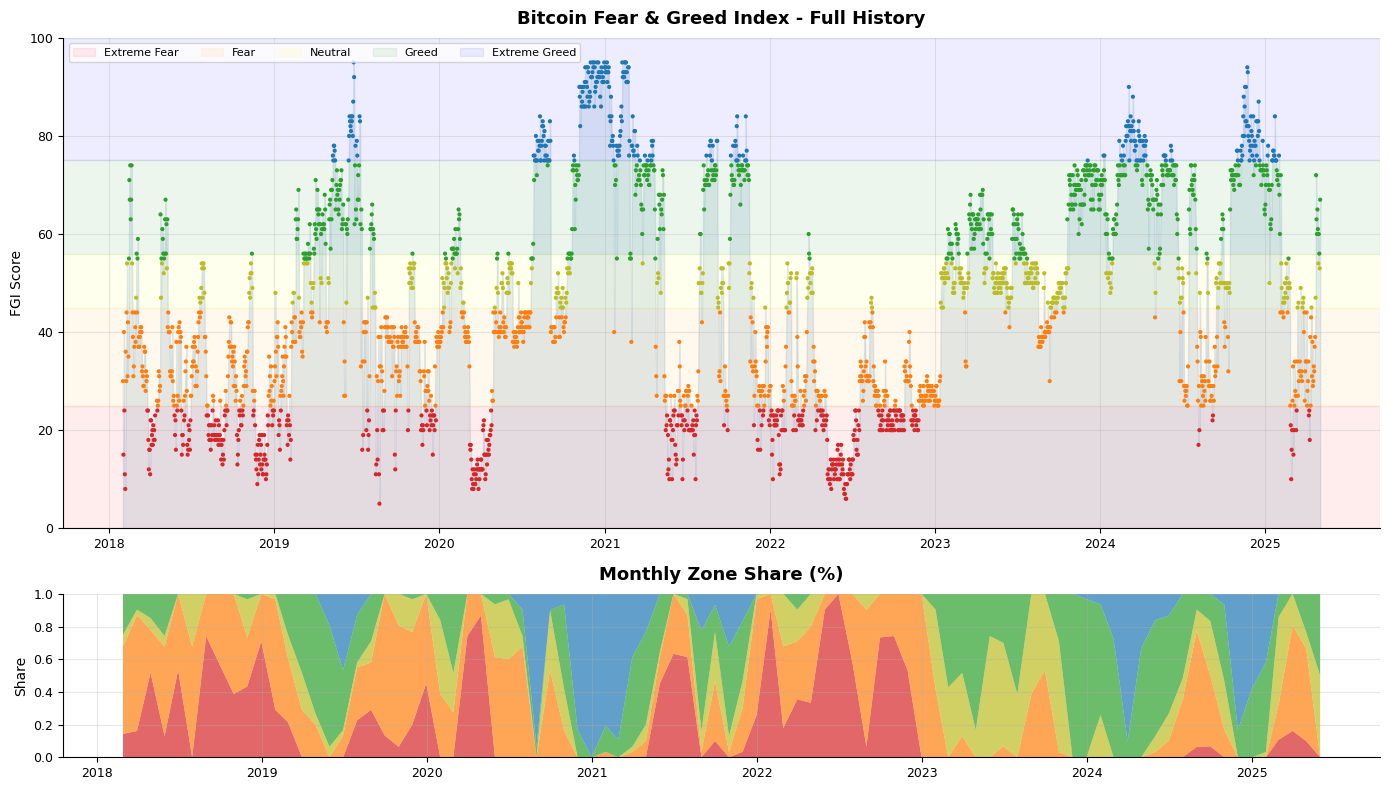

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
zone_colors_list = fg["classification"].map(COLORS)
ax.fill_between(fg["date"], fg["value"], alpha=0.15, color="steelblue")
ax.scatter(fg["date"], fg["value"], c=zone_colors_list, s=4, zorder=3)

ax.axhspan(0, 25, alpha=0.07, color="red", label="Extreme Fear")
ax.axhspan(25, 45, alpha=0.07, color="orange", label="Fear")
ax.axhspan(45, 56, alpha=0.07, color="yellow", label="Neutral")
ax.axhspan(56, 75, alpha=0.07, color="green", label="Greed")
ax.axhspan(75, 100, alpha=0.07, color="blue", label="Extreme Greed")

ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
style_axes(ax, "Bitcoin Fear & Greed Index - Full History", "", "FGI Score")
ax.legend(loc="upper left", fontsize=8, ncol=5)

ax2 = axes[1]
monthly = (
    fg.groupby([pd.Grouper(key="date", freq="ME"), "classification"], observed=False)
      .size()
      .unstack(fill_value=0)
      .reindex(columns=ZONE_ORDER, fill_value=0)
)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0).fillna(0)
stack_values = [monthly_pct[zone].to_numpy() for zone in ZONE_ORDER]
ax2.stackplot(
    monthly_pct.index,
    *stack_values,
    labels=ZONE_ORDER,
    colors=[COLORS[zone] for zone in ZONE_ORDER],
    alpha=0.7,
)
style_axes(ax2, "Monthly Zone Share (%)", "", "Share")
ax2.set_ylim(0, 1)

plt.tight_layout()
save_fig("01_fgi_timeline")
plt.show()


## 2B — Sentiment Zone Distribution

Saved -> C:\project\trading_sentiment_project\outputs\charts\02_zone_distribution.png


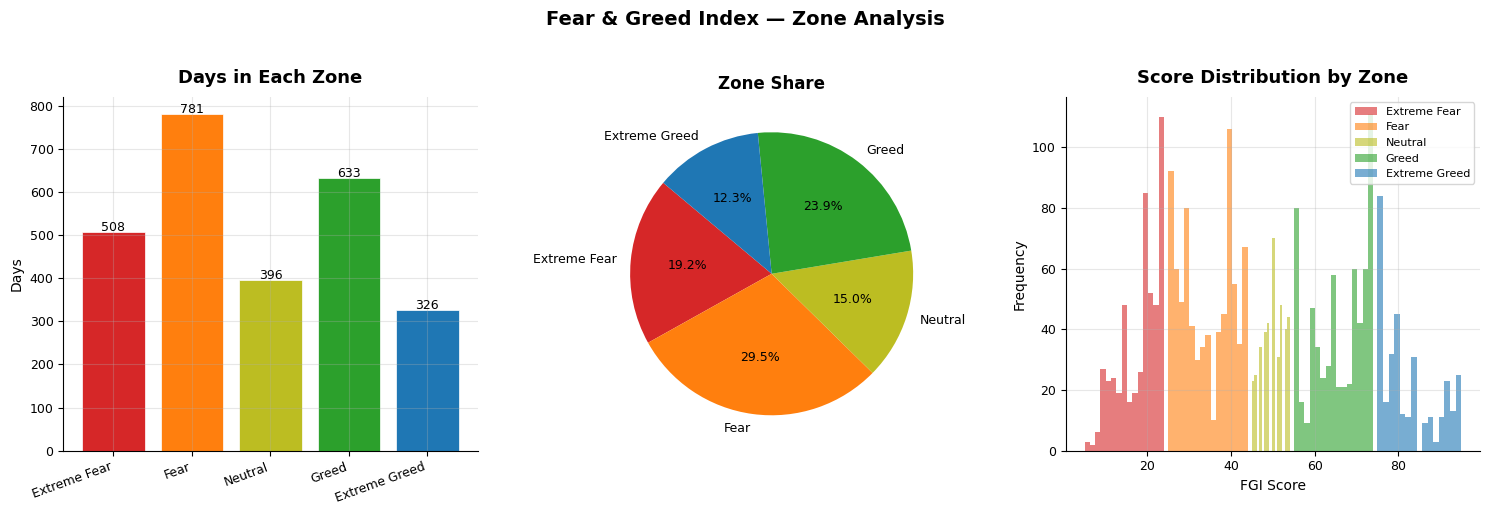

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Count
zone_counts = fg['classification'].value_counts().reindex(ZONE_ORDER).fillna(0)
colors = [COLORS[z] for z in ZONE_ORDER]

axes[0].bar(ZONE_ORDER, zone_counts, color=colors, edgecolor='white', linewidth=0.5)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')
style_axes(axes[0], 'Days in Each Zone', '', 'Days')
for i, v in enumerate(zone_counts):
    axes[0].text(i, v + 2, str(int(v)), ha='center', fontsize=9)

# Pie
axes[1].pie(zone_counts, labels=ZONE_ORDER, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Zone Share', fontweight='bold')

# Score distribution by zone
for zone in ZONE_ORDER:
    subset = fg[fg['classification'] == zone]['value']
    if len(subset) > 0:
        axes[2].hist(subset, bins=15, alpha=0.6, color=COLORS[zone], label=zone)
style_axes(axes[2], 'Score Distribution by Zone', 'FGI Score', 'Frequency')
axes[2].legend(fontsize=8)

plt.suptitle('Fear & Greed Index — Zone Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('02_zone_distribution')
plt.show()


## 2C — Trades Dataset Overview

In [4]:
print('=== TRADES DATASET SUMMARY ===')
print(f'Total trades              : {len(tr):,}')

if 'account' in tr.columns:
    print(f'Unique traders            : {tr["account"].nunique():,}')

if 'symbol' in tr.columns:
    print(f'Unique symbols            : {tr["symbol"].nunique():,}')
    print(f'Top 5 symbols:\n{tr["symbol"].value_counts().head()}')

if 'side' in tr.columns:
    print(f'\nSide distribution:\n{tr["side"].value_counts()}')

if 'closedPnL' in tr.columns:
    closed = tr[tr['closedPnL'].notna()]
    print(f'\n--- Closed PnL stats (on {len(closed):,} closed trades) ---')
    print(closed['closedPnL'].describe())

=== TRADES DATASET SUMMARY ===
Total trades              : 211,224
Unique traders            : 32
Unique symbols            : 246
Top 5 symbols:
symbol
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

Side distribution:
side
SELL    108528
BUY     102696
Name: count, dtype: int64

--- Closed PnL stats (on 211,224 closed trades) ---
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: closedPnL, dtype: float64


Saved -> C:\project\trading_sentiment_project\outputs\charts\03_trades_overview.png


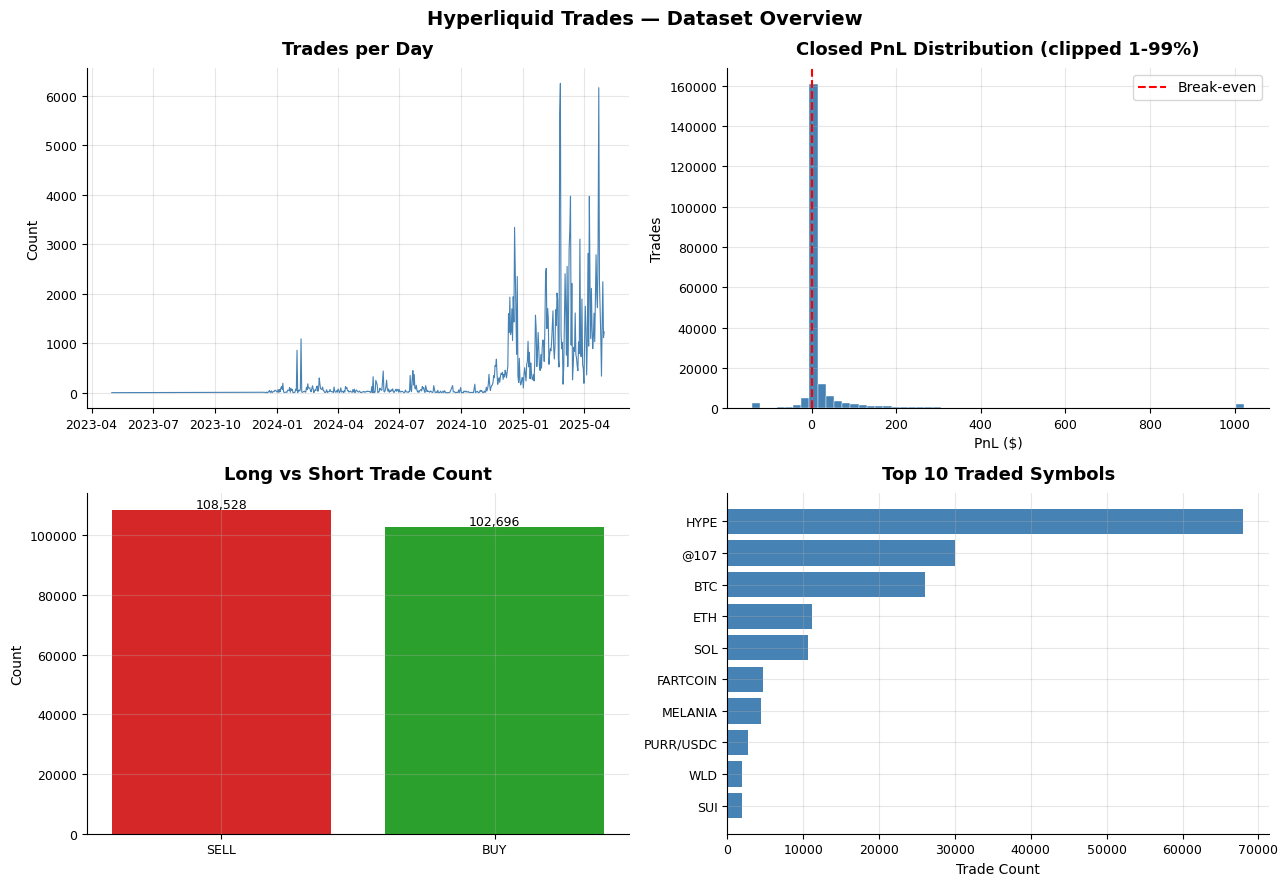

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Trades per day ────────────────────────────────────────────────
if 'date' in tr.columns:
    daily_count = tr.groupby('date').size()
    axes[0,0].plot(daily_count.index, daily_count.values, lw=0.8, color='steelblue')
    style_axes(axes[0,0], 'Trades per Day', '', 'Count')

# ── PnL distribution ──────────────────────────────────────────────
if 'closedPnL' in tr.columns:
    pnl_data = tr['closedPnL'].dropna()
    # Clip for readability (remove extreme outliers in chart only)
    p1, p99 = pnl_data.quantile([0.01, 0.99])
    clipped = pnl_data.clip(p1, p99)
    axes[0,1].hist(clipped, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0,1].axvline(0, color='red', lw=1.5, linestyle='--', label='Break-even')
    style_axes(axes[0,1], 'Closed PnL Distribution (clipped 1-99%)', 'PnL ($)', 'Trades')
    axes[0,1].legend()

# ── Side breakdown ────────────────────────────────────────────────
if 'side' in tr.columns:
    side_counts = tr['side'].value_counts()
    axes[1,0].bar(side_counts.index, side_counts.values,
                  color=['#2ca02c' if s == 'BUY' else '#d62728' for s in side_counts.index])
    style_axes(axes[1,0], 'Long vs Short Trade Count', '', 'Count')
    for i, (label, v) in enumerate(side_counts.items()):
        axes[1,0].text(i, v + len(tr)*0.003, f'{v:,}', ha='center', fontsize=9)

# ── Top 10 symbols ────────────────────────────────────────────────
if 'symbol' in tr.columns:
    top10 = tr['symbol'].value_counts().head(10)
    axes[1,1].barh(top10.index[::-1], top10.values[::-1], color='steelblue')
    style_axes(axes[1,1], 'Top 10 Traded Symbols', 'Trade Count', '')

plt.suptitle('Hyperliquid Trades — Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig('03_trades_overview')
plt.show()

## 2D — Leverage Distribution

In [6]:
if 'leverage' in tr.columns and tr['leverage'].notna().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    lev = tr['leverage'].dropna()
    axes[0].hist(lev, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    style_axes(axes[0], 'Leverage Distribution', 'Leverage (x)', 'Trades')

    # Bucketed
    bins   = [0, 3, 5, 10, 20, 200]
    labels = ['1-3x', '3-5x', '5-10x', '10-20x', '20x+']
    tr['lev_bucket'] = pd.cut(tr['leverage'], bins=bins, labels=labels)
    lev_counts = tr['lev_bucket'].value_counts().reindex(labels)
    axes[1].bar(labels, lev_counts, color='darkorange', edgecolor='white')
    style_axes(axes[1], 'Trades by Leverage Bucket', 'Leverage Bucket', 'Count')

    plt.suptitle('Leverage Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('04_leverage_dist')
    plt.show()
else:
    print('No leverage column found — skipping.')

No leverage column found — skipping.


## 2E — Merged Dataset Quick Look

In [7]:
print('Merged dataset columns:', merged.columns.tolist())
print('\nZone distribution in merged dataset:')
print(merged['classification'].value_counts().reindex(ZONE_ORDER))
merged.describe()

Merged dataset columns: ['account', 'symbol', 'exec_price', 'size_tokens', 'size_usd', 'side', 'time', 'start_position', 'direction', 'closedPnL', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'batch_timestamp', 'date', 'is_win', 'fgi_score', 'classification', 'zone', 'has_sentiment']

Zone distribution in merged dataset:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


,exec_price,size_tokens,size_usd,time,start_position,closedPnL,order_id,fee,trade_id,batch_timestamp,date,fgi_score
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009280,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28.674014464,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN,21.012784
